In [1]:
import optuna
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score, KFold

# データセットの読み込み
X, y = load_diabetes(return_X_y=True)

# Optunaの目的関数を定義
def objective(trial):
    # ハイパーパラメータの提案（alphaの範囲を0.1から10.0）
    alpha = trial.suggest_float('alpha', 0.1, 10.0)
    
    # Ridge回帰モデルを作成
    model = Ridge(alpha=alpha)
    
    # 5分割交差検証で評価（scoringはneg_mean_squared_error）
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')
    
    # 平均負のMSEを返す（Optunaはこれを最小化する）
    return -np.mean(scores)

# Optunaによるハイパーパラメータの探索
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)

# 最適なハイパーパラメータの出力
print("Best alpha:", study.best_params['alpha'])
print("Best score:", study.best_value)

[I 2024-11-14 10:39:25,037] A new study created in memory with name: no-name-14b32309-e0e3-4c93-b753-0df268392c09
[I 2024-11-14 10:39:25,472] Trial 0 finished with value: 4689.029094922754 and parameters: {'alpha': 6.3204635246892}. Best is trial 0 with value: 4689.029094922754.
[I 2024-11-14 10:39:25,484] Trial 1 finished with value: 3379.181586541678 and parameters: {'alpha': 0.8865275828493097}. Best is trial 1 with value: 3379.181586541678.
[I 2024-11-14 10:39:25,495] Trial 2 finished with value: 4401.268845501526 and parameters: {'alpha': 4.345747902434056}. Best is trial 1 with value: 3379.181586541678.
[I 2024-11-14 10:39:25,507] Trial 3 finished with value: 4936.476183114747 and parameters: {'alpha': 8.894816259088921}. Best is trial 1 with value: 3379.181586541678.
[I 2024-11-14 10:39:25,518] Trial 4 finished with value: 4851.394502125907 and parameters: {'alpha': 7.881598040158634}. Best is trial 1 with value: 3379.181586541678.
[I 2024-11-14 10:39:25,530] Trial 5 finished wi

Best alpha: 0.10055181006025689
Best score: 3013.9042912241603


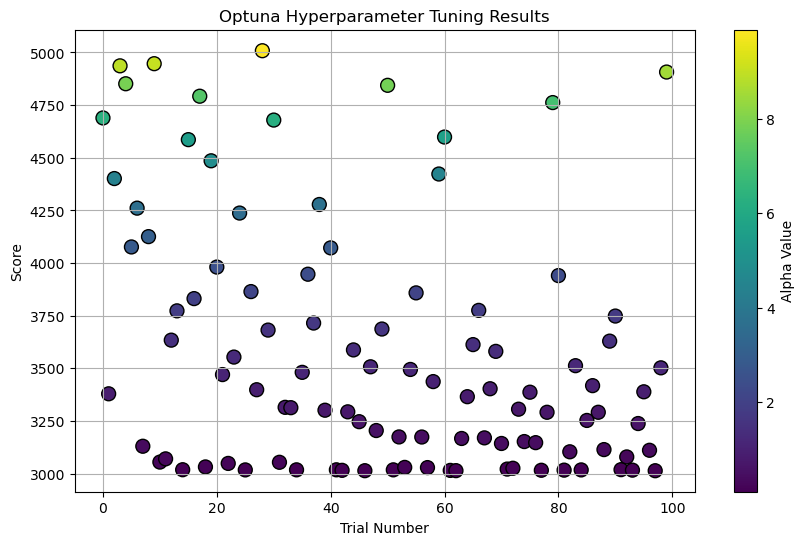

In [2]:
import matplotlib.pyplot as plt
import optuna

# Optunaの試行結果を含むstudyオブジェクトを読み込む
# study = optuna.load_study(...) # あなたの環境に合わせてstudyオブジェクトを取得してください

# 試行結果の取得
trials = study.trials

# 各試行の番号とスコア、アルファ値の取得
trial_numbers = [trial.number for trial in trials]
scores = [trial.value for trial in trials]
alphas = [trial.params['alpha'] for trial in trials]

# プロットの作成
plt.figure(figsize=(10, 6))
scatter = plt.scatter(trial_numbers, scores, c=alphas, cmap='viridis', edgecolor='k', s=100)
plt.colorbar(scatter, label='Alpha Value')
plt.xlabel('Trial Number')
plt.ylabel('Score')
plt.title('Optuna Hyperparameter Tuning Results')
plt.grid(True)
plt.show()